
## Latar Belakang

Dogecoin, yang awalnya diciptakan sebagai meme cryptocurrency, kini telah berkembang menjadi salah satu aset digital yang cukup populer di dunia. Dengan komunitas yang besar dan penggunaan yang semakin luas, Dogecoin menarik perhatian banyak investor dan trader yang tertarik dengan potensi pertumbuhannya di pasar cryptocurrency. Dogecoin memiliki karakteristik unik, seperti biaya transaksi yang rendah dan waktu transaksi yang cepat, yang memberikan keunggulan dibandingkan dengan beberapa cryptocurrency lainnya.

Sebagai cryptocurrency yang berada di pasar yang sangat volatil, fluktuasi harga Dogecoin seringkali dipengaruhi oleh berbagai faktor eksternal, termasuk sentimen pasar, adopsi teknologi blockchain, dan pengaruh dari tokoh publik seperti Elon Musk. Oleh karena itu, prediksi harga Dogecoin menjadi penting bagi investor dan trader untuk mengambil keputusan yang lebih terinformasi dalam kegiatan investasi mereka.

Dalam rangka mendukung tujuan investasi dan keputusan strategis di pasar cryptocurrency, analisis prediksi harga Dogecoin dapat memberikan wawasan yang lebih mendalam mengenai faktor-faktor yang mempengaruhi harga serta proyeksi harga yang lebih akurat. Prediksi harga yang tepat dapat membantu mengoptimalkan portofolio investasi serta mengelola risiko yang terkait dengan volatilitas pasar cryptocurrency.

## Tujuan

Analisis prediksi harga Dogecoin bertujuan untuk memberikan wawasan yang lebih mendalam tentang fluktuasi harga Dogecoin dengan menggunakan model prediksi yang akurat. Prediksi yang baik dapat membantu investor dalam mengambil keputusan yang tepat mengenai pembelian, penjualan, atau alokasi aset Dogecoin dalam portofolio investasi mereka. Dengan demikian, analisis ini berperan penting dalam menjaga kestabilan dan pertumbuhan investasi di pasar cryptocurrency.

## Rumusan Masalah

1. Bagaimana cara memprediksi harga Dogecoin secara efektif?
2. Algoritma apa yang paling cocok untuk memprediksi harga Dogecoin?
3. Seberapa akurat prediksi harga Dogecoin yang dihasilkan?

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import gdown

# ID file dari URL Google Drive
file_id = '16kXDWFkXFL4Oun0TGNYDsFdV2RlL_yaf'

# Membuat URL unduhan
url = f'https://drive.google.com/uc?id={file_id}'

# Mengunduh file
output = 'dogecoin_data.csv'  # Nama file CSV yang akan disimpan
gdown.download(url, output, quiet=False)

# Menampilkan pesan sukses
print(f"File telah berhasil diunduh sebagai {output}")

Downloading...
From: https://drive.google.com/uc?id=16kXDWFkXFL4Oun0TGNYDsFdV2RlL_yaf
To: /content/dogecoin_data.csv
100%|██████████| 253k/253k [00:00<00:00, 49.2MB/s]

File telah berhasil diunduh sebagai dogecoin_data.csv


In [ ]:
import pandas as pd

# Membaca file CSV yang telah diunduh
data = pd.read_csv('dogecoin_data.csv')

# Menampilkan 5 baris pertama dari data
print(data.head())


                        Date     Price  Adj Close     Close      High  \
0  2019-09-01 00:00:00+00:00  0.002492   0.002492  0.002533  0.002443   
1  2019-09-02 00:00:00+00:00  0.002596   0.002596  0.002616  0.002462   
2  2019-09-03 00:00:00+00:00  0.002595   0.002595  0.002724  0.002560   
3  2019-09-04 00:00:00+00:00  0.002690   0.002690  0.002695  0.002541   
4  2019-09-05 00:00:00+00:00  0.002531   0.002531  0.002692  0.002505   

        Low      Open  Volume  
0  0.002512  22742519     NaN  
1  0.002492  25999239     NaN  
2  0.002598  40548612     NaN  
3  0.002596  27623103     NaN  
4  0.002690  32285101     NaN  


In [ ]:
# Mengecek apakah ada data yang sama
print(data.duplicated().sum())

0


In [ ]:
# Mengecek apakah ada nilai yang hilang (missing values)
print(data.isnull().sum())

Date            0
Price           0
Adj Close       0
Close           0
High            0
Low             0
Open            0
Volume       1827
dtype: int64


In [ ]:
# Mengubah kolom Date menjadi indeks
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Menampilkan 5 baris pertama untuk memastikan data
print(data.head())

# Menghitung korelasi hanya untuk kolom numerik
print(data.corr())

                              Price  Adj Close     Close      High       Low  \
Date                                                                           
2019-09-01 00:00:00+00:00  0.002492   0.002492  0.002533  0.002443  0.002512   
2019-09-02 00:00:00+00:00  0.002596   0.002596  0.002616  0.002462  0.002492   
2019-09-03 00:00:00+00:00  0.002595   0.002595  0.002724  0.002560  0.002598   
2019-09-04 00:00:00+00:00  0.002690   0.002690  0.002695  0.002541  0.002596   
2019-09-05 00:00:00+00:00  0.002531   0.002531  0.002692  0.002505  0.002690   

                               Open  Volume  
Date                                         
2019-09-01 00:00:00+00:00  22742519     NaN  
2019-09-02 00:00:00+00:00  25999239     NaN  
2019-09-03 00:00:00+00:00  40548612     NaN  
2019-09-04 00:00:00+00:00  27623103     NaN  
2019-09-05 00:00:00+00:00  32285101     NaN  
              Price  Adj Close     Close      High       Low      Open  Volume
Price      1.000000   1.000000  0.9940

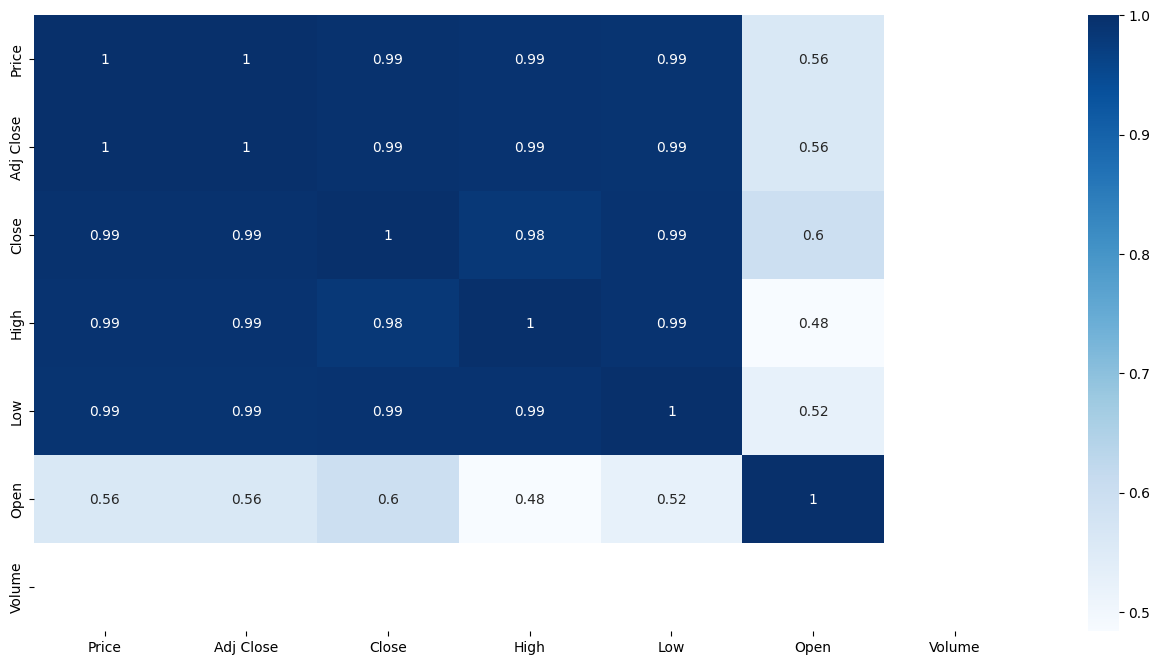

In [ ]:
#heat map of all variable
plt.figure(figsize=(16,8))
sns.heatmap(data.corr(), cmap="Blues", annot=True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Menghitung Z-score untuk mendeteksi outlier
z_scores = np.abs((data["Close"] - data["Close"].mean()) / data["Close"].std())

# Menampilkan nilai Z-score untuk beberapa baris pertama
print(z_scores.head())

# Menampilkan data yang terdeteksi sebagai outlier (Z-score > 3)
outliers = data[z_scores > 3]
print("Outliers detected:\n", outliers)

# Menghapus baris yang terdeteksi sebagai outlier (Z-score > 3)
cleaned_data = data[z_scores <= 3]

# Menampilkan data setelah outlier dihapus
print("Data setelah outlier dihapus:\n", cleaned_data.head())

Date
2019-09-01 00:00:00+00:00    0.953833
2019-09-02 00:00:00+00:00    0.953001
2019-09-03 00:00:00+00:00    0.951919
2019-09-04 00:00:00+00:00    0.952210
2019-09-05 00:00:00+00:00    0.952240
Name: Close, dtype: float64
Outliers detected:
                               Price  Adj Close     Close      High       Low  \
Date                                                                           
2021-04-16 00:00:00+00:00  0.365870   0.365870  0.437700  0.180488  0.181587   
2021-04-19 00:00:00+00:00  0.407318   0.407318  0.431751  0.309080  0.320466   
2021-04-20 00:00:00+00:00  0.319500   0.319500  0.422347  0.271618  0.408435   
2021-05-01 00:00:00+00:00  0.392987   0.392987  0.397135  0.328290  0.337559   
2021-05-02 00:00:00+00:00  0.376046   0.376046  0.400029  0.364874  0.391087   
2021-05-03 00:00:00+00:00  0.441707   0.441707  0.445567  0.373631  0.373631   
2021-05-04 00:00:00+00:00  0.541334   0.541334  0.605998  0.400800  0.440274   
2021-05-05 00:00:00+00:00  0.657633  

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalisasi menggunakan MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[["Close", "High", "Low", "Open", "Adj Close"]])

# Mengonversi kembali hasil scaling menjadi DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=["Close", "High", "Low", "Open", "Adj Close"])

# Menampilkan hasil scaling
print(scaled_data.head())


      Close      High       Low      Open  Adj Close
0  0.001251  0.001971  0.001416  0.000000   0.001398
1  0.001364  0.002002  0.001387  0.000047   0.001550
2  0.001511  0.002163  0.001542  0.000257   0.001549
3  0.001472  0.002132  0.001539  0.000070   0.001688
4  0.001467  0.002073  0.001676  0.000138   0.001455


In [ ]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
X = scaled_data[["High", "Low", "Open", "Adj Close"]]  # Fitur
y = scaled_data["Close"]  # Target (Harga Close)

# Membagi data menjadi 80% untuk training dan 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Fungsi untuk menghitung MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100



Training set: (1461, 4)
Test set: (366, 4)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Membuat dan melatih model regresi linier
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Memprediksi harga menggunakan data uji
y_pred = lr_model.predict(X_test)

# Evaluasi model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Linear Regression - MAE:", mae)
print("Linear Regression - MSE:", mse)
print("Linear Regression - R2:", r2)
print("Linear Regression - MAPE: {:.2f}%".format(mape))


Linear Regression - MAE: 0.0021023510486180693
Linear Regression - MSE: 2.271060814569749e-05
Linear Regression - R2: 0.9985509564964343
Linear Regression - MAPE: 3.48%


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Membuat dan melatih model Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Memprediksi harga menggunakan data uji
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

print("Random Forest - MAE:", mae_rf)
print("Random Forest - MSE:", mse_rf)
print("Random Forest - R2:", r2_rf)
print("Random Forest - MAPE: {:.2f}%".format(mape_rf))


Random Forest - MAE: 0.002181072442429968
Random Forest - MSE: 3.972342914814242e-05
Random Forest - R2: 0.9974654585831787
Random Forest - MAPE: 2.03%


In [ ]:
from sklearn.svm import SVR

# Membuat dan melatih model SVM
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)

# Memprediksi harga menggunakan data uji
y_pred_svm = svm_model.predict(X_test)

# Evaluasi model
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)
mape_svm = mean_absolute_percentage_error(y_test, y_pred_svm)

print("SVM - MAE:", mae_svm)
print("SVM - MSE:", mse_svm)
print("SVM - R2:", r2_svm)
print("SVM - MAPE: {:.2f}%".format(mape_svm))


SVM - MAE: 0.08011967226125688
SVM - MSE: 0.006718307606086109
SVM - R2: 0.5713404093320396
SVM - MAPE: 2232.81%


In [ ]:
from sklearn.neural_network import MLPRegressor

# Membuat dan melatih model Neural Network
nn_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)

# Memprediksi harga menggunakan data uji
y_pred_nn = nn_model.predict(X_test)

# Evaluasi model
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)
mape_nn = mean_absolute_percentage_error(y_test, y_pred_nn)

print("Neural Network - MAE:", mae_nn)
print("Neural Network - MSE:", mse_nn)
print("Neural Network - R2:", r2_nn)
print("Neural Network - MAPE: {:.2f}%".format(mape_nn))

Neural Network - MAE: 0.003433260765937675
Neural Network - MSE: 4.448434738322592e-05
Neural Network - R2: 0.997161689631009
Neural Network - MAPE: 62.88%
